In [36]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.model_selection import train_test_split

In [37]:
titanic = sns.load_dataset("titanic")

In [38]:
# the data we will use. features and target
features= ["pclass", "sex", "fare", "embarked", "age"]
target= ["survived"]

In [39]:
# fill missing values using simple imputer

from sklearn.impute import SimpleImputer

imp_median=SimpleImputer(strategy="median")
titanic[["age"]]=imp_median.fit_transform(titanic[["age"]])

imp_freq=SimpleImputer(strategy="most_frequent")
titanic[["embarked"]]=imp_freq.fit_transform(titanic[["embarked"]])


In [40]:
# encoding

from sklearn.preprocessing import LabelEncoder

le=LabelEncoder()

titanic["sex"]=le.fit_transform(titanic["sex"])
titanic["embarked"]=le.fit_transform(titanic["embarked"])

In [41]:
X=titanic[features]
y=titanic[target]

In [42]:
X_train, X_test, y_train, y_test= train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [43]:
# Decision tree model
from sklearn.tree import DecisionTreeClassifier

model=DecisionTreeClassifier()

model.fit(X_train,y_train)
y_pred=model.predict(X_test)

In [44]:
from sklearn.metrics import accuracy_score

print("Accuracy: ",accuracy_score(y_test,y_pred))

Accuracy:  0.7653631284916201


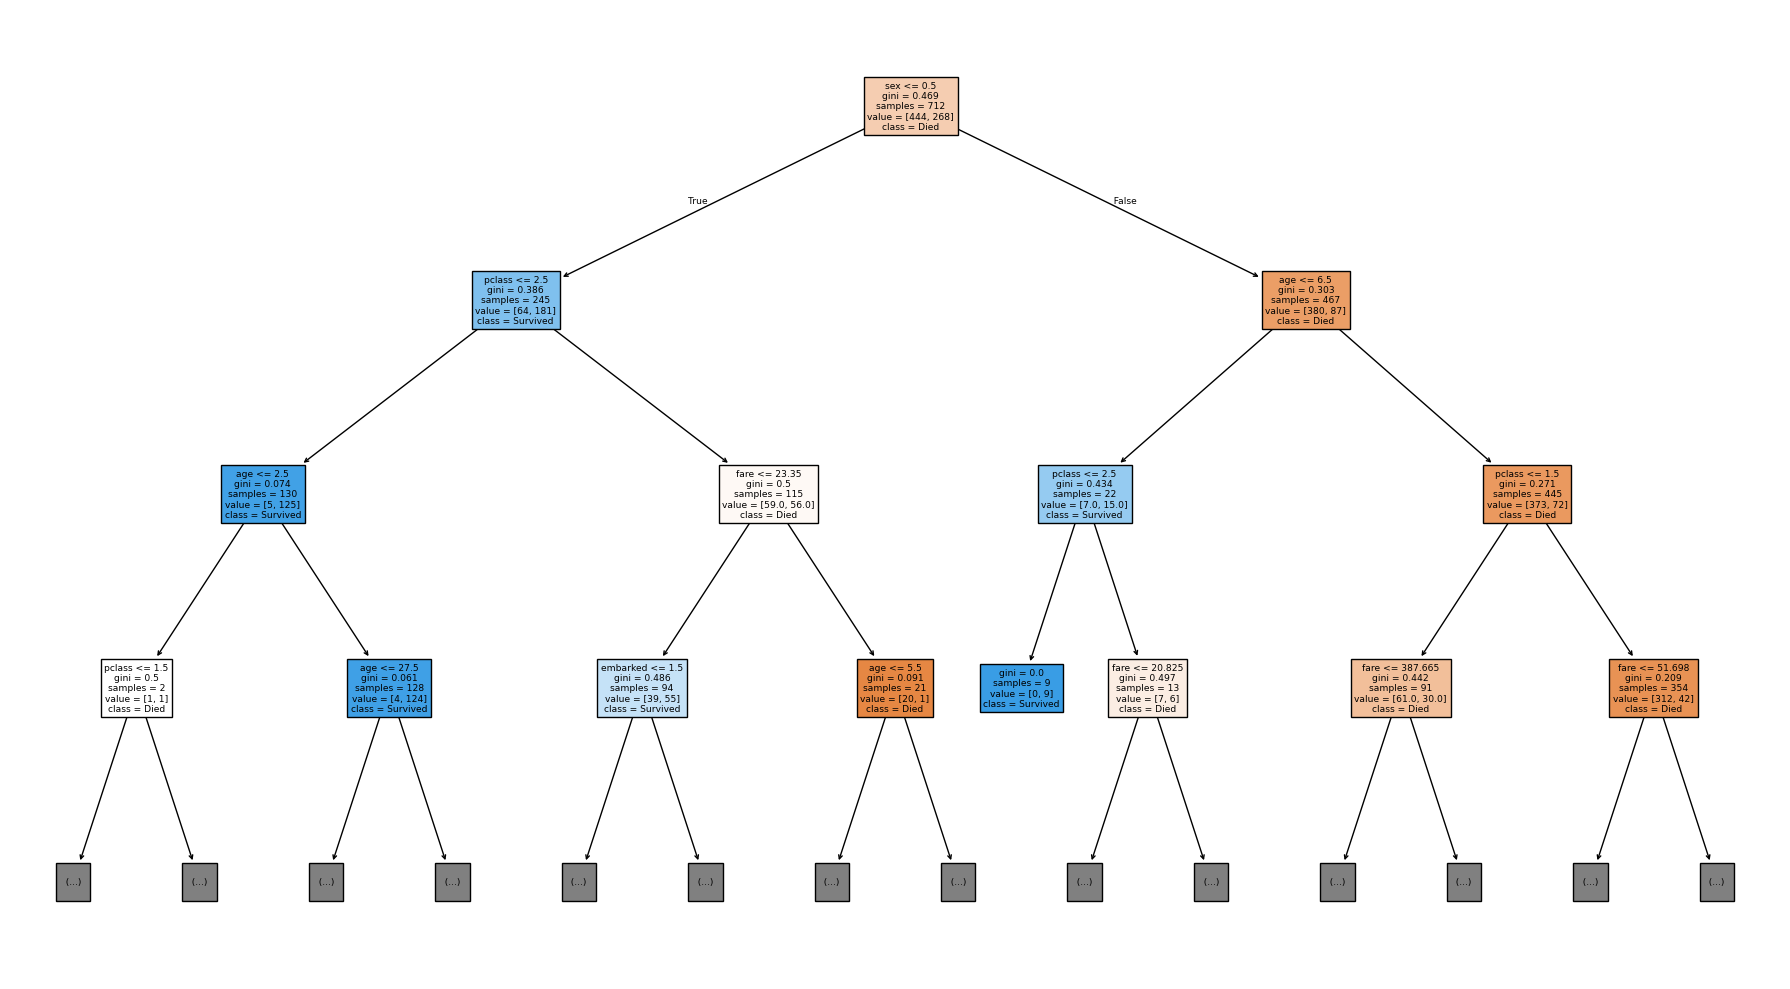

In [45]:
# plot tree
from sklearn.tree import plot_tree

plt.figure(figsize=(18,10))

plot_tree(
    model,
    feature_names=X.columns,
    class_names=["Died","Survived"],
    filled=True,
    max_depth=3
)
plt.tight_layout()
plt.show()

 Depth:2   Accuracy:0.7653631284916201
 Depth:3   Accuracy:0.7988826815642458
 Depth:4   Accuracy:0.7988826815642458


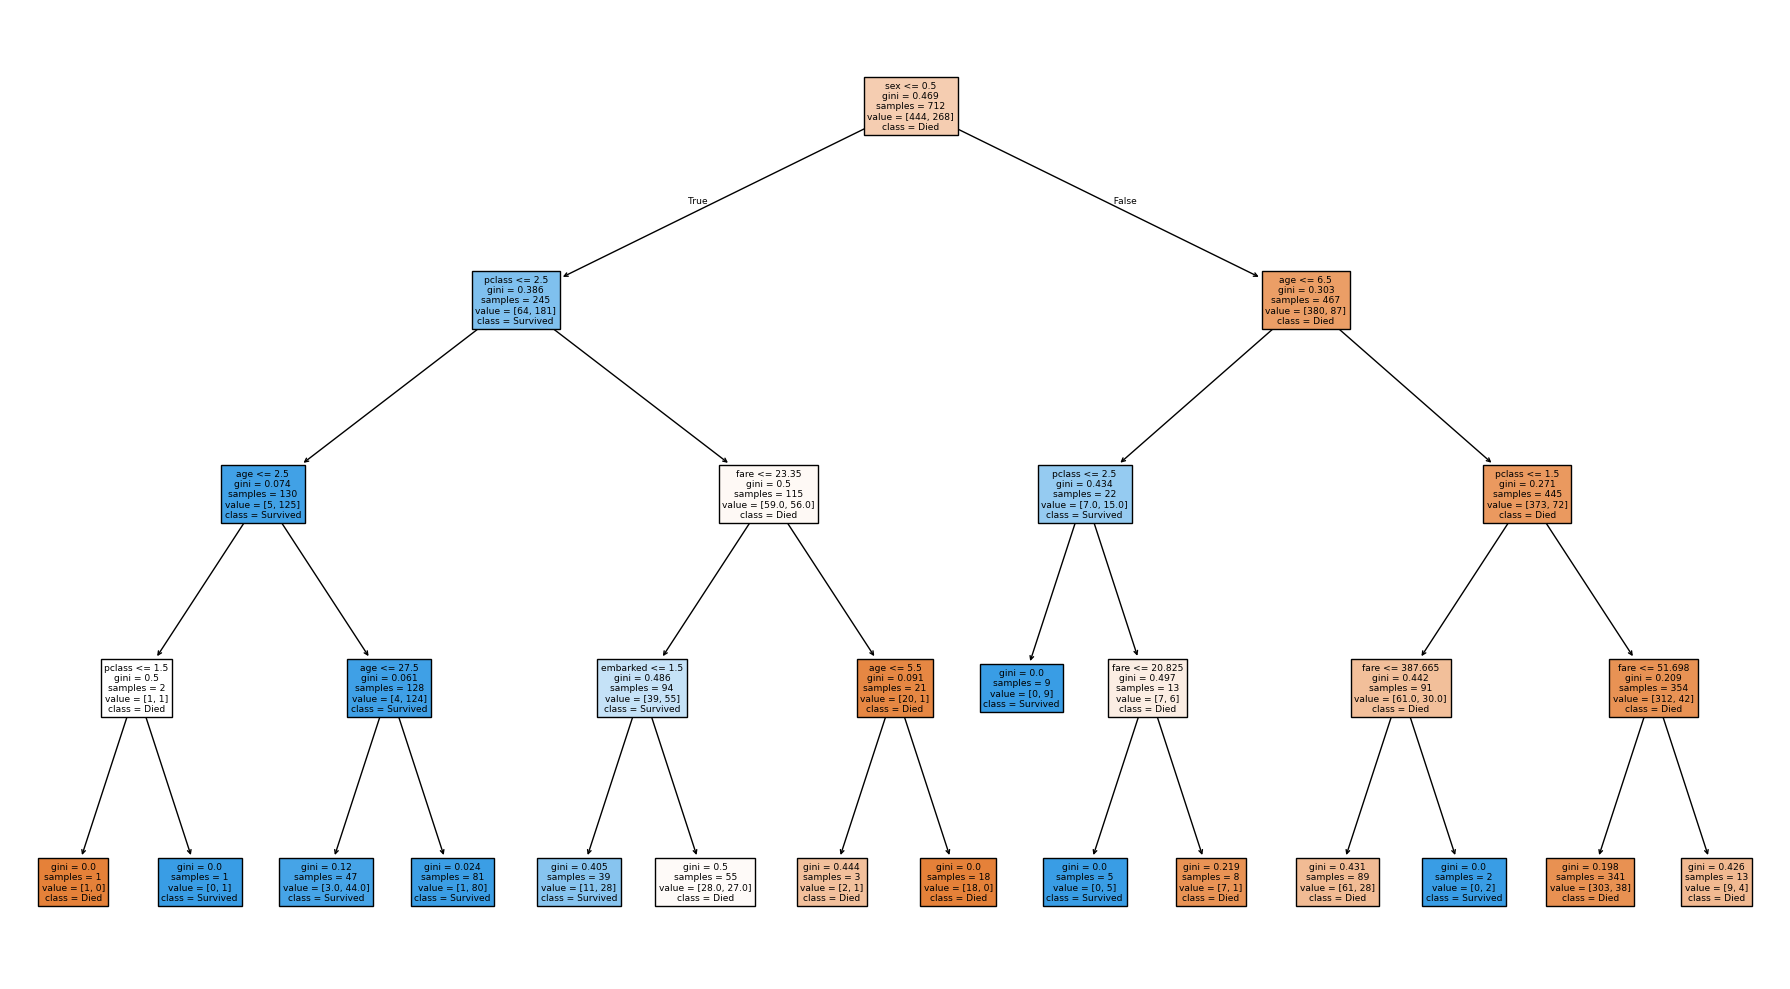

 Depth:5   Accuracy:0.7988826815642458
 Depth:6   Accuracy:0.8044692737430168
 Depth:7   Accuracy:0.7988826815642458
 Depth:8   Accuracy:0.7988826815642458
 Depth:9   Accuracy:0.7932960893854749
 Depth:10   Accuracy:0.7877094972067039


In [52]:
# Decision Tree wit pre_pruning
max_depths=[2,3,4,5,6,7,8,9,10]

for depth in max_depths:
    model=DecisionTreeClassifier(max_depth=depth)
    model.fit(X_train,y_train)
    acc=model.score(X_test,y_test)
    print(f" Depth:{depth}   Accuracy:{acc}")

    #plot the best tree
    if depth==4:
        plt.figure(figsize=(18,10))

        plot_tree(
            model,
            feature_names=X.columns,
            class_names=["Died","Survived"],
            filled=True,
        )
        plt.tight_layout()
        plt.show()

 for sample splits:5   Accuracy:0.776536312849162
 for sample splits:10   Accuracy:0.8156424581005587
 for sample splits:15   Accuracy:0.8156424581005587
 for sample splits:20   Accuracy:0.8212290502793296


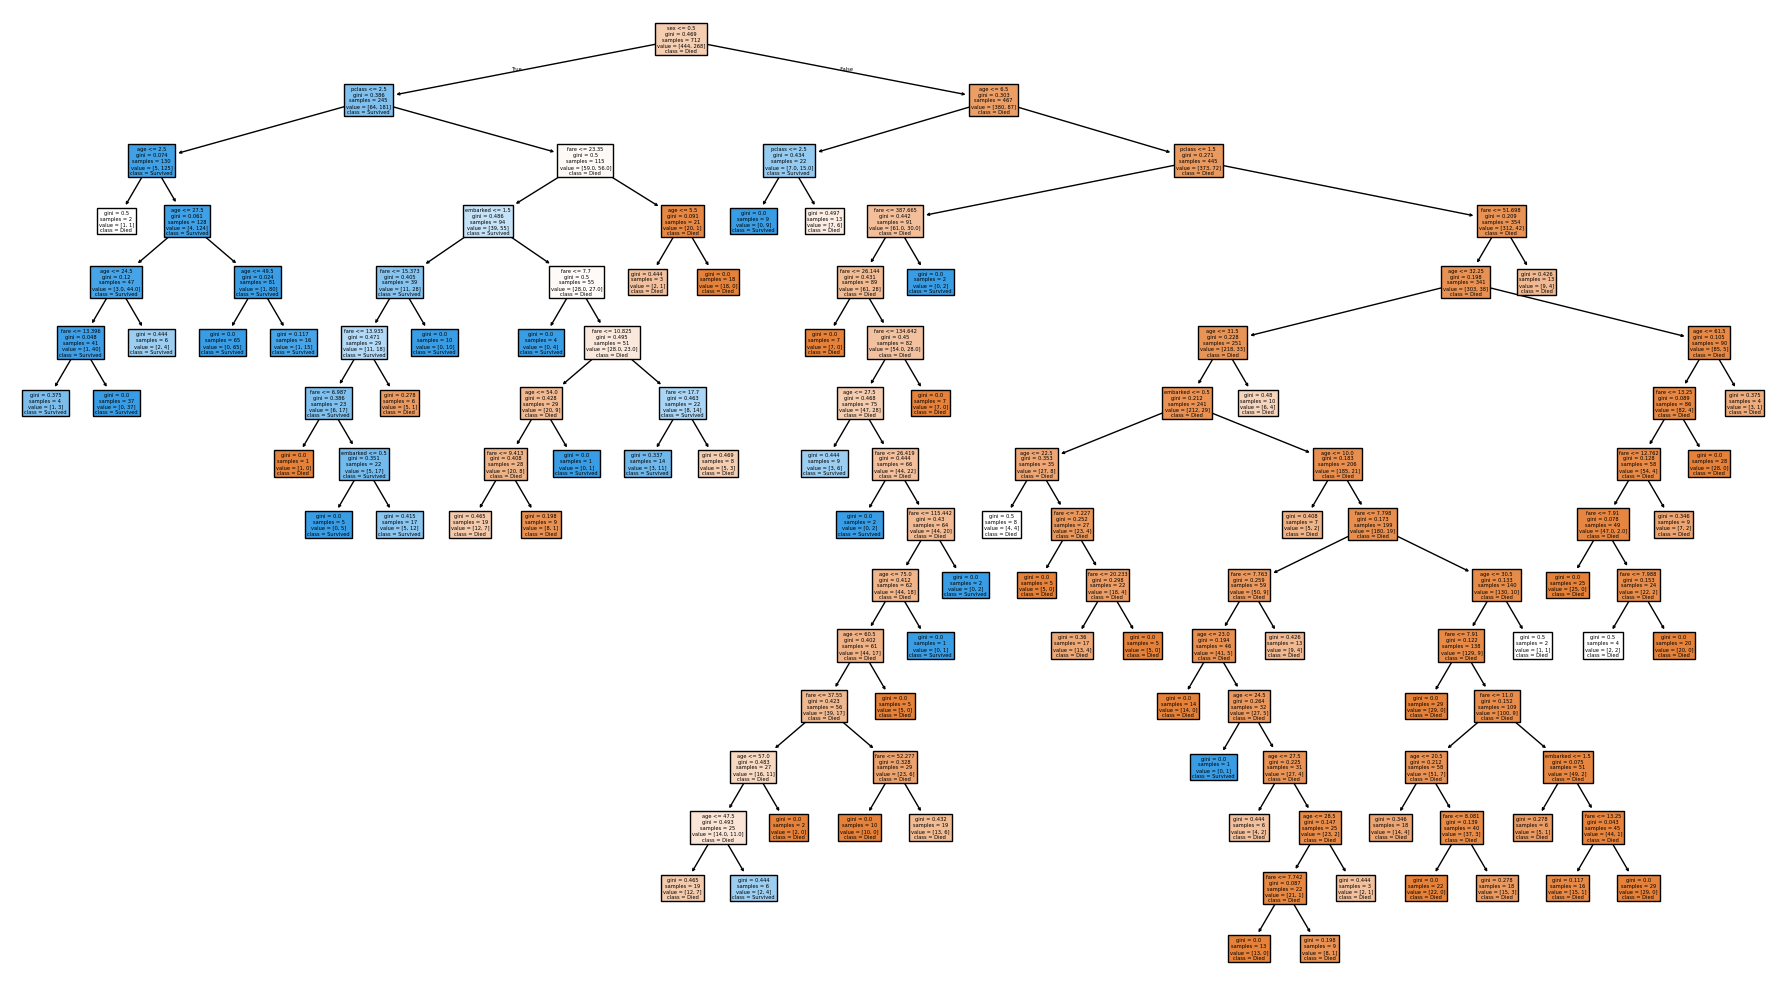

 for sample splits:25   Accuracy:0.8044692737430168
 for sample splits:30   Accuracy:0.7988826815642458


In [53]:
min_sample_splits=[5,10,15,20,25,30]

for split in min_sample_splits:
    model=DecisionTreeClassifier(min_samples_split=split)
    model.fit(X_train,y_train)
    acc=model.score(X_test,y_test)
    print(f" for sample splits:{split}   Accuracy:{acc}")

    #plot the best tree
    if split==20:
        plt.figure(figsize=(18,10))

        plot_tree(
            model,
            feature_names=X.columns,
            class_names=["Died","Survived"],
            filled=True,
        )
        plt.tight_layout()
        plt.show()

In [75]:
# Decision Tree wit post_pruning

# Train a full tree
full_tree = DecisionTreeClassifier(random_state=42)
full_tree.fit(X_train, y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [76]:
# Get all possible ccp_alpha values
path = full_tree.cost_complexity_pruning_path(X_train, y_train)
ccp_alphas = path.ccp_alphas

In [77]:
best_acc = 0
best_alpha = 0

# Find the best alpha
for alpha in ccp_alphas:
    model = DecisionTreeClassifier(
        random_state=42,
        ccp_alpha=alpha
    )
    model.fit(X_train, y_train)

    acc = model.score(X_test, y_test)

    if acc > best_acc:
        best_acc = acc
        best_alpha = alpha

print("Best Alpha:", best_alpha)
print("Best Accuracy:", best_acc)


Best Alpha: 0.0015407231242023183
Best Accuracy: 0.8379888268156425


In [78]:
# Train final model
best_model = DecisionTreeClassifier(
    random_state=42,
    ccp_alpha=best_alpha
)
best_model.fit(X_train, y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


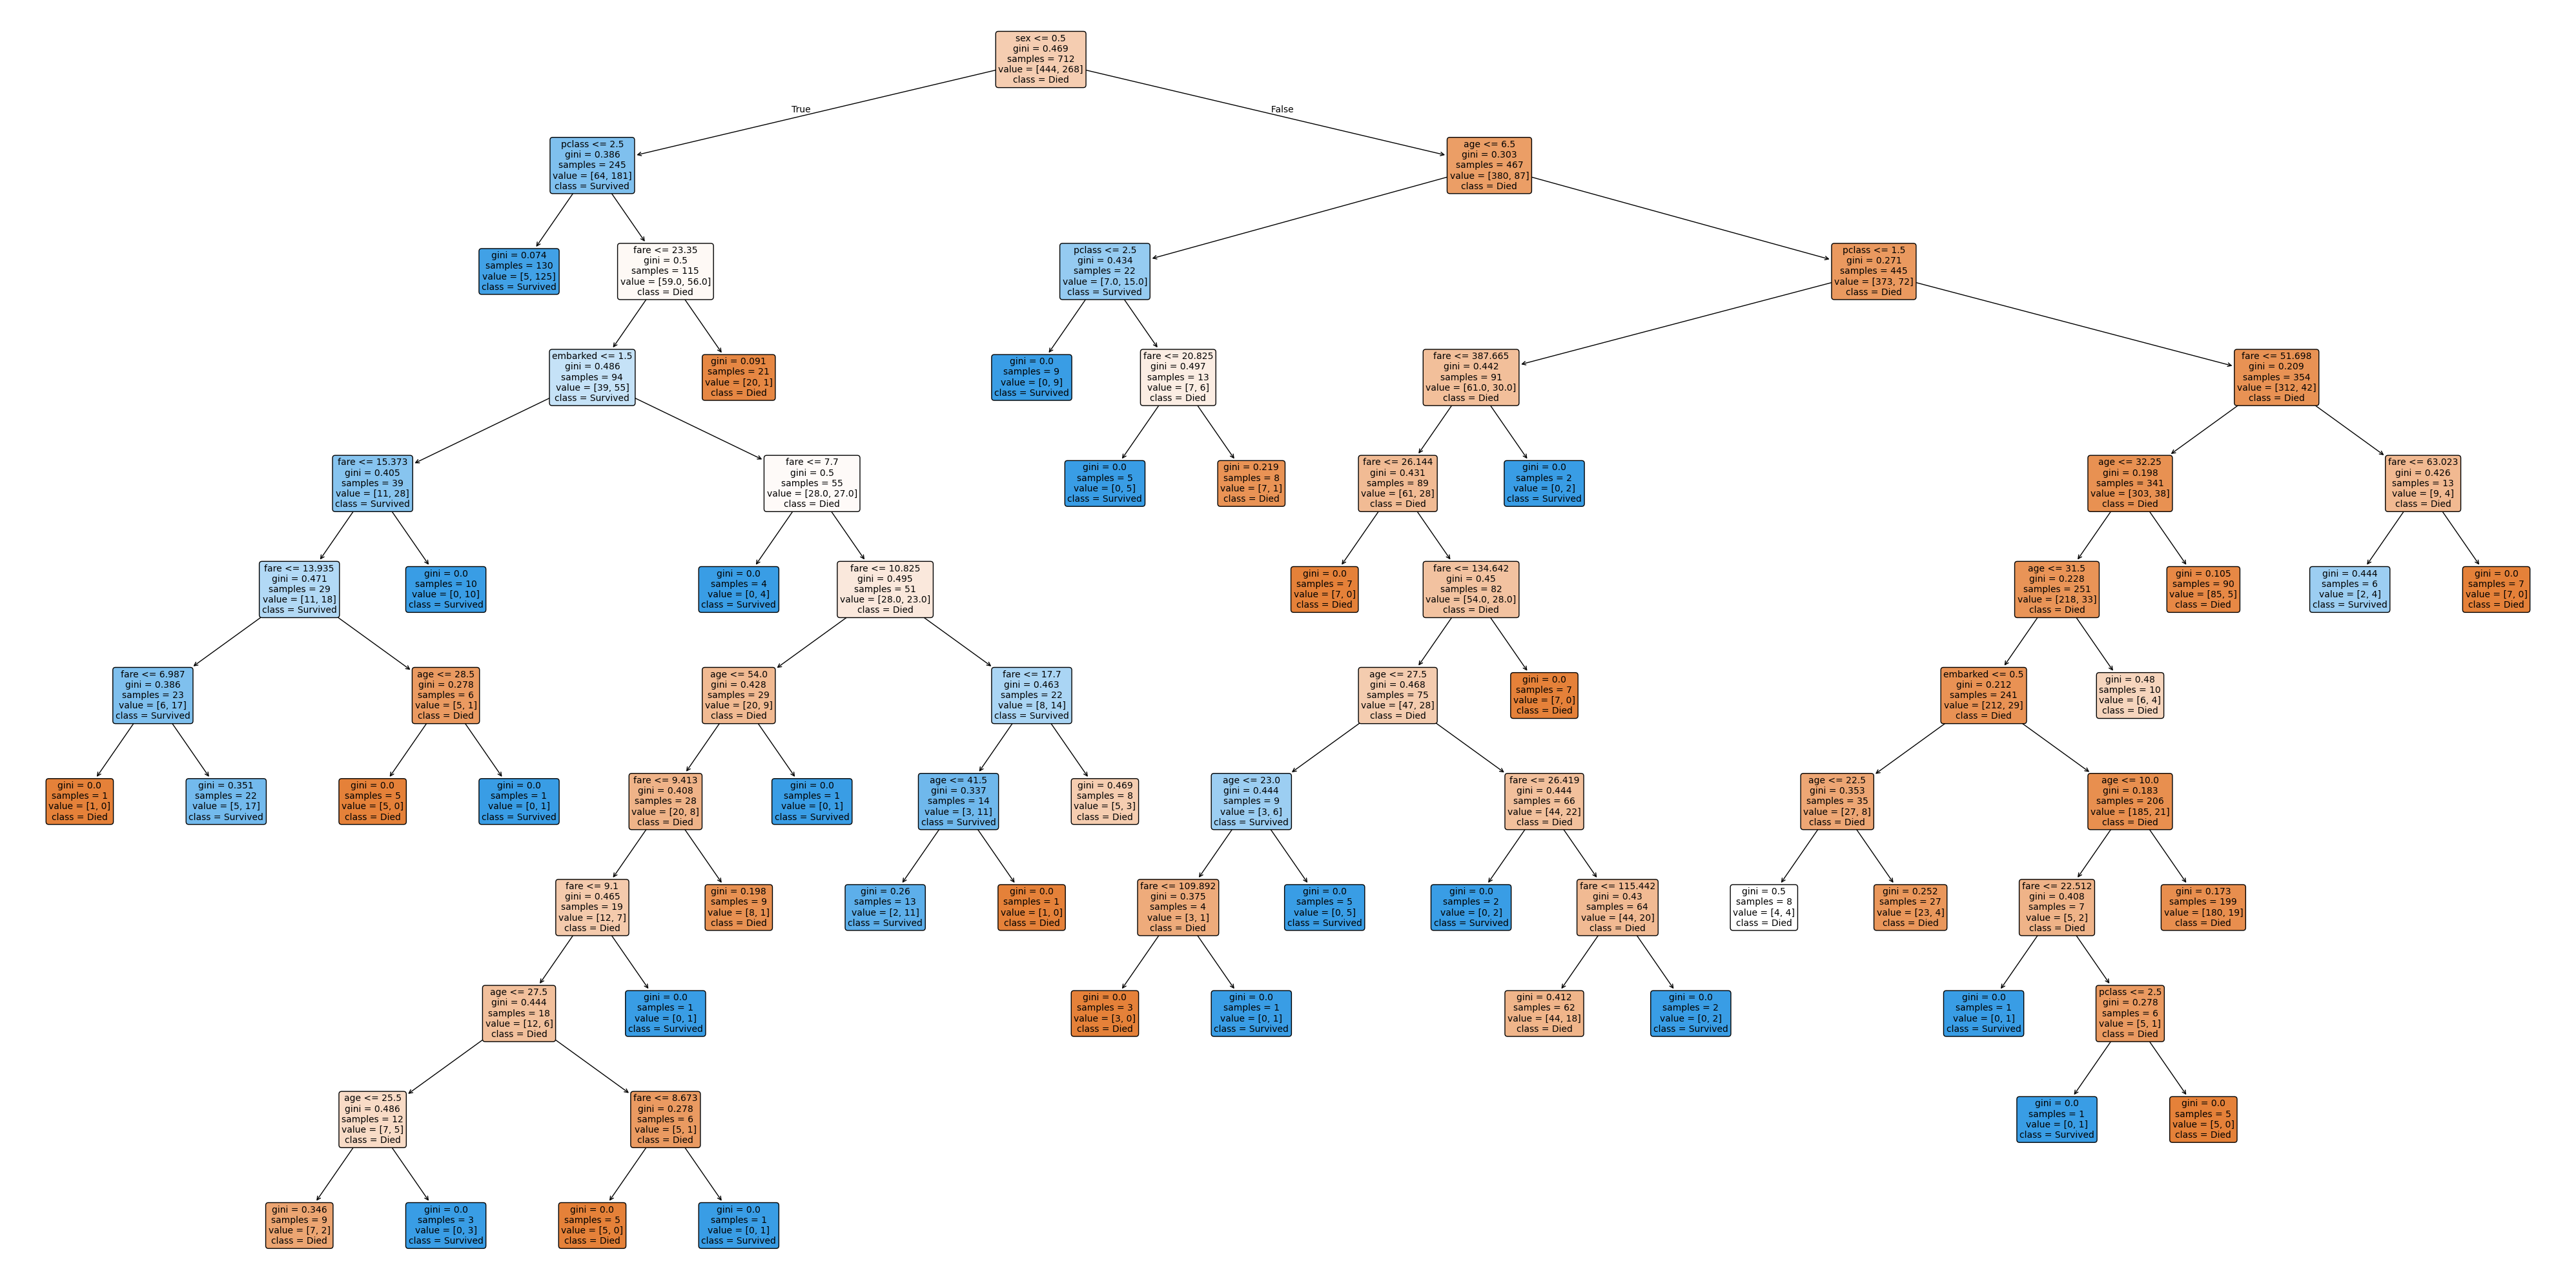

In [81]:
# Plot the tree
plt.figure(figsize=(40, 20))

plot_tree(
    best_model,
    feature_names=X.columns,
    class_names=["Died", "Survived"],
    filled=True,
    rounded=True,
    fontsize=10
)

plt.tight_layout()
plt.show()

In [87]:
# Cross validation. using GridSearchCV

from sklearn.model_selection import GridSearchCV
param_grid = {
    "ccp_alpha": ccp_alphas
}

grid = GridSearchCV(
    DecisionTreeClassifier(random_state=42),
    param_grid,
    cv=5,
    scoring="accuracy"
)

grid.fit(X_train, y_train)

best_model = grid.best_estimator_



In [88]:
print("Best Alpha:", grid.best_params_["ccp_alpha"])
print("Best CV Accuracy:", grid.best_score_)

best_model = grid.best_estimator_

print("Test Accuracy:", best_model.score(X_test, y_test))

# grid.best_score_ is the average cross-validation accuracy, while best_model.score(X_test, y_test) is the accuracy on test set

Best Alpha: 0.001761447615767647
Best CV Accuracy: 0.8146656160740668
Test Accuracy: 0.8324022346368715


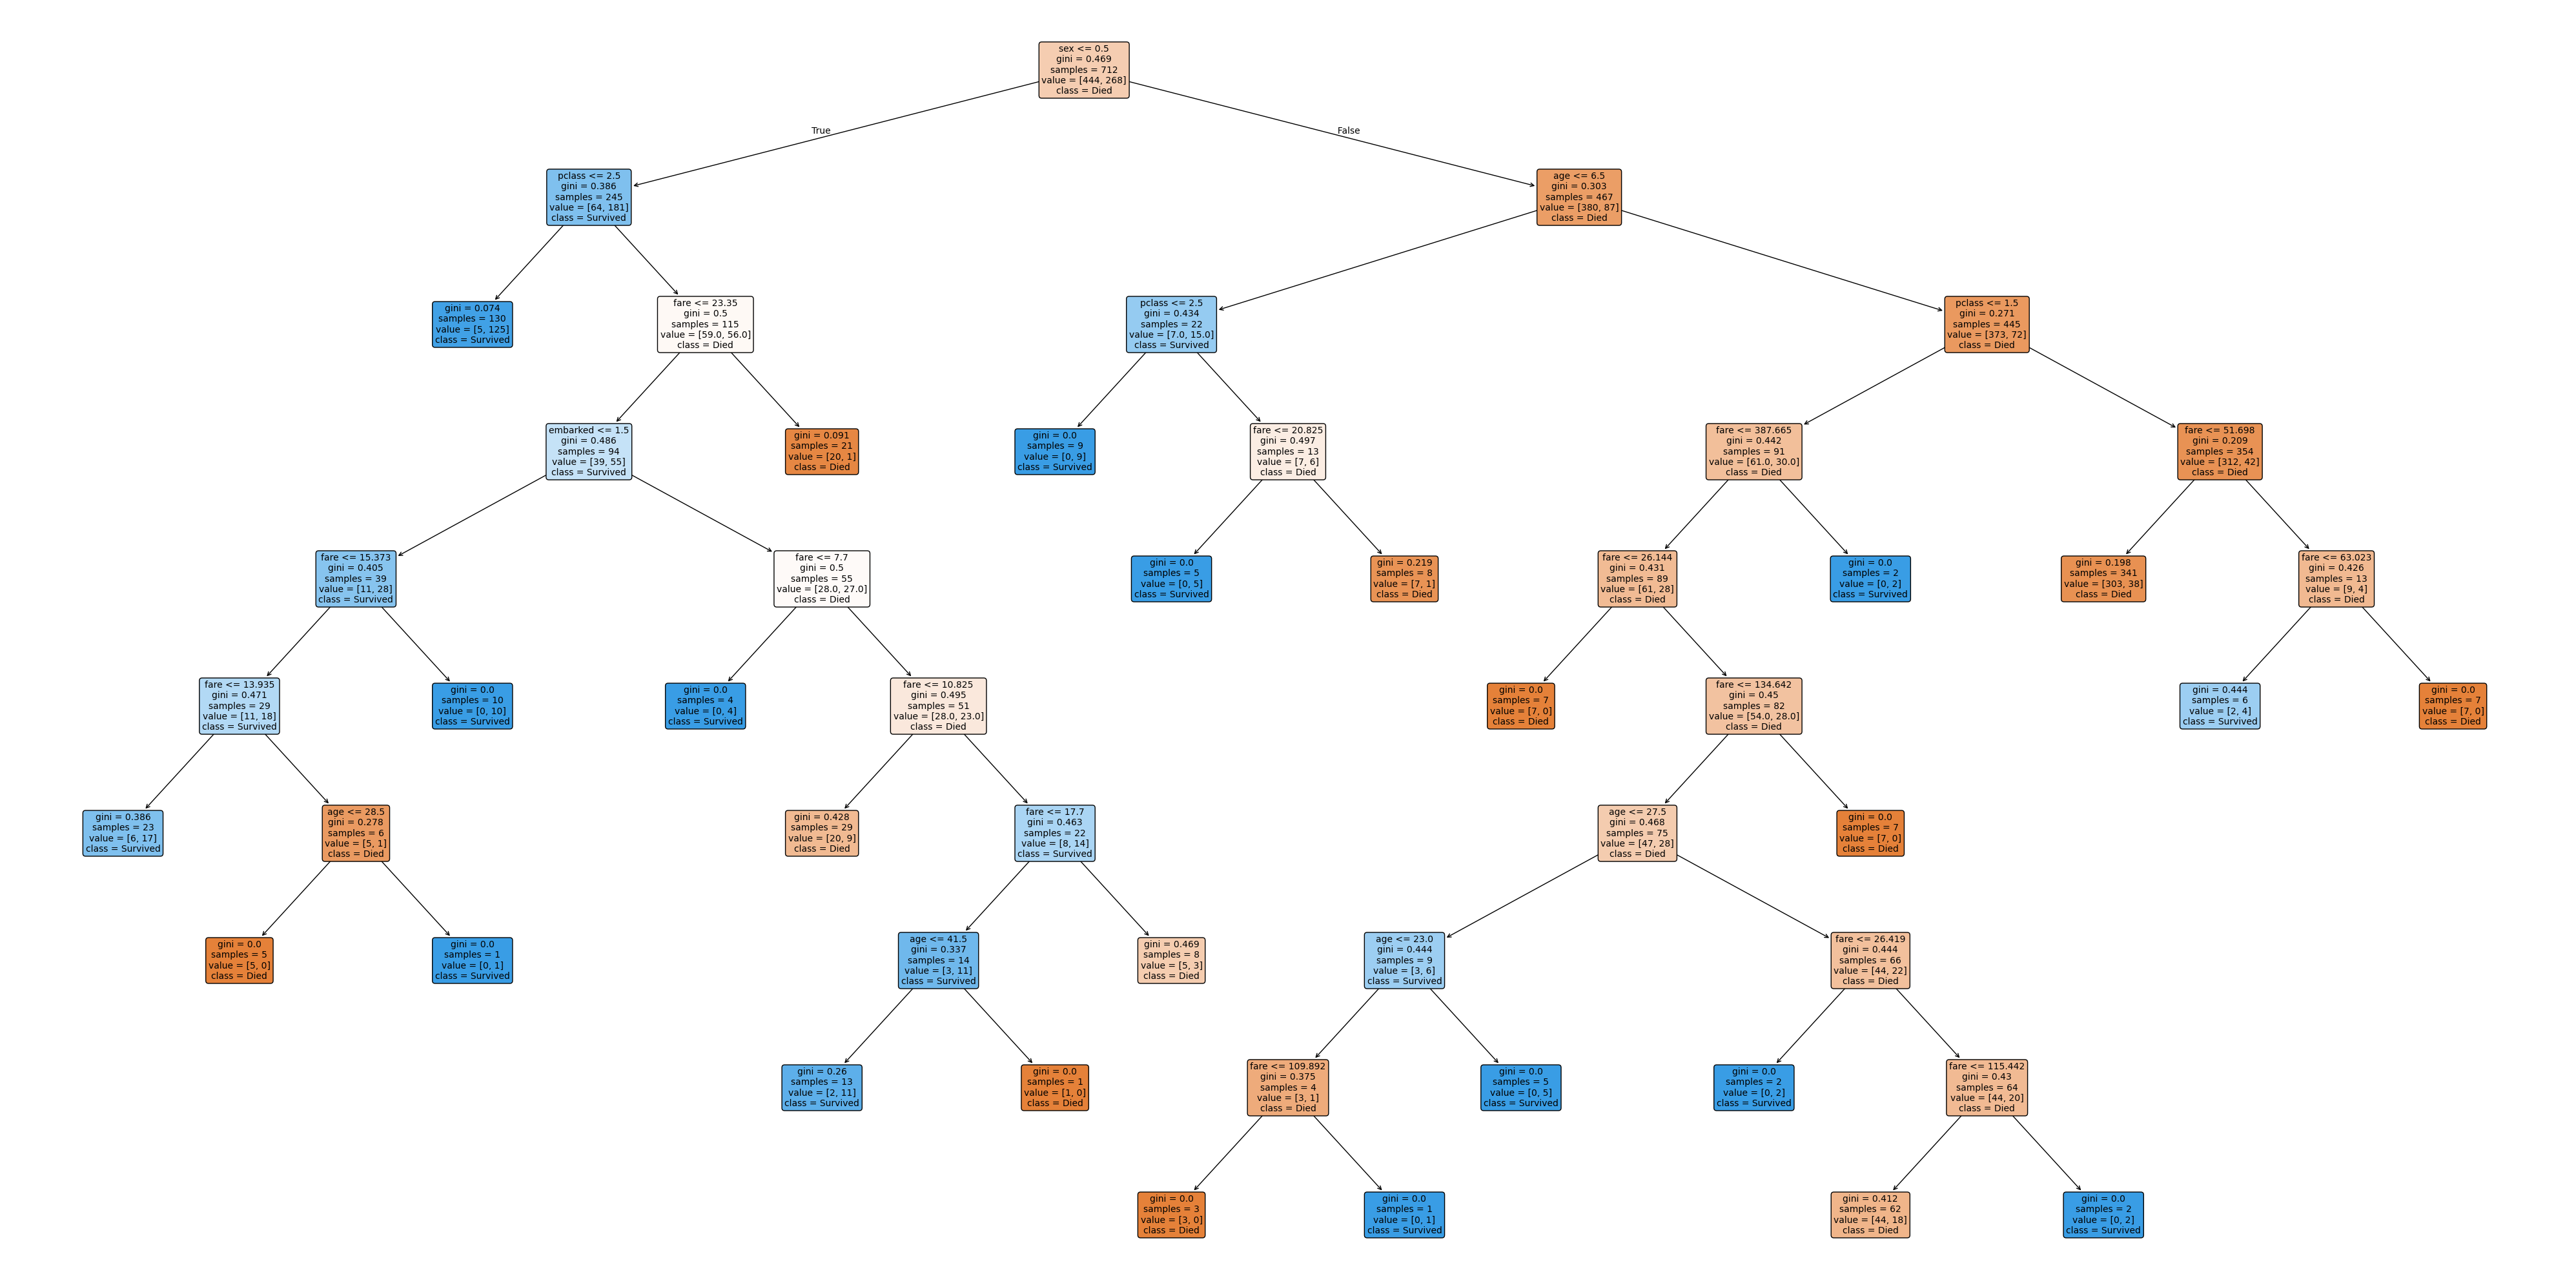

In [89]:
# Plot the tree
plt.figure(figsize=(40, 20))

plot_tree(
    best_model,
    feature_names=X.columns,
    class_names=["Died", "Survived"],
    filled=True,
    rounded=True,
    fontsize=10
)

plt.tight_layout()
plt.show()